This notebook trains an XGBoost tree according to our training model and displays various metrics such as AUC and AMS. This notebook does not include: the other two tree classes, or the ability to save and/or load a pre-trained tree. To see these features and obtain the learning curve or the average AUC with cross-validation, you can check out our complete work in the BDT folder on GitHub.

Click “Run All” to execute the code

In [1]:
COLAB = "google.colab" in str(get_ipython()) # detects if we're running on colab
print ("COLAB=",COLAB)

fullrun=True #if run all modules (slow!)
#fullrun=False #if run a subset to get started


COLAB= True


In [2]:
if COLAB:
    ! git clone --depth 1 https://github.com/blackSwanCS/Higgs_collaborations.git

    ! git status
    %cd Higgs_collaborations

Cloning into 'Higgs_collaborations'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 18 (delta 1), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 1.17 MiB | 20.32 MiB/s, done.
Resolving deltas: 100% (1/1), done.
fatal: not a git repository (or any of the parent directories): .git
/content/Higgs_collaborations


In [12]:
# HiggsML utility package should not be modified
%pip install HiggsML==0.1.5
%pip install xgboost

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split

In [14]:
import os

root_dir = os.getcwd()
print("Root directory is", root_dir)
submission_dir = os.path.join(root_dir, "sample_code_submission")


output_dir = os.path.join(root_dir, "sample_result_submission")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

Root directory is /content/Higgs_collaborations


In [15]:
class XGBoost_BDT:
    """
    Classificateur XGBoost autonome pour le dataset Higgs.
    Intègre sa propre standardisation, l'early stopping et applique
    strictement la philosophie de gestion des poids du professeur.
    """

    def __init__(self):
        self.scaler = StandardScaler()

        self.model = XGBClassifier(
            n_estimators=5000,
            learning_rate=0.01,
            max_depth=8,
            subsample=0.950,
            colsample_bytree=0.7,
            reg_alpha=0.1,
            reg_lambda=1.0,
            use_label_encoder=False,
            eval_metric="logloss",
            early_stopping_rounds=15,
            random_state=42,
        )

    def fit(self, train_data, labels, weights=None):
        # On définit la taille du set de validation interne (10%)
        val_size = 0.1

        # 1. Création du set de validation interne pour l'early stopping
        if weights is not None:
            X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
                train_data, labels, weights,
                test_size=val_size, random_state=42, stratify=labels
            )

            # --- ALIGNEMENT DES POIDS D'ENTRAÎNEMENT (w_tr) ---

            class_weights_tr = (w_tr[y_tr == 0].sum(), w_tr[y_tr == 1].sum())
            for i in [0, 1]:
                if class_weights_tr[i] > 0:
                    w_tr[y_tr == i] *= max(class_weights_tr) / class_weights_tr[i]

            # Comme le set de validation ne prend que 10% des données, on multiplie les poids par 1 / 0.1 (soit 10)
            for i in [0, 1]:
                w_val[y_val == i] *= 1 / val_size

        else:
            X_tr, X_val, y_tr, y_val = train_test_split(
                train_data, labels,
                test_size=val_size, random_state=42, stratify=labels
            )
            w_tr = w_val = None

        X_tr = self.scaler.fit_transform(X_tr)
        X_val = self.scaler.transform(X_val)


        if weights is None:
            neg = np.sum(y_tr == 0)
            pos = np.sum(y_tr == 1)
            self.model.set_params(scale_pos_weight=neg / pos if pos > 0 else 1.0)

        # Entraînement final avec Early Stopping
        self.model.fit(
            X_tr, y_tr,
            sample_weight=w_tr,
            eval_set=[(X_val, y_val)],
            sample_weight_eval_set=[w_val] if w_val is not None else None,
            verbose=False,
        )

        print("Best iteration:", self.model.best_iteration)
        print("Best score:", self.model.best_score)

    def predict(self, test_data):
        test_data = self.scaler.transform(test_data)
        return self.model.predict_proba(test_data)[:, 1]


In [16]:
from HiggsML.datasets import download_dataset


def get_clean_splits():
    """
    Télécharge et prépare les données HiggsML.
    Découpe en 80% Train (pour le fit) et 20% Test (pour le predict).

    Retourne:
        X_train, X_test, y_train, y_test, w_train, w_test
    """
    data = download_dataset(
    "blackSwan_data")
    data.load_train_set()
    data_set = data.get_train_set()

    y = data_set["labels"]
    w = data_set["weights"]
    X = data_set.drop(columns=["labels", "weights", "detailed_labels"], errors="ignore")

    #  Découpage macro (80% Train / 20% Test local)
    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, w, test_size=0.20, random_state=42, stratify=y
    )

    return X_train, X_test, y_train, y_test, w_train, w_test

In [17]:
def training_tree():
    """
    Entraîne XGBoost"""
    X_train, X_test, y_train, y_test, w_train, w_test = get_clean_splits()

    bdt = XGBoost_BDT()
    bdt.fit(X_train, y_train, weights=w_train)
    predictions = bdt.predict(X_test)

    return X_train, X_test, y_train, y_test, w_train, w_test, bdt, predictions


In [18]:
def amsasimov(s_in, b_in):
    """Calcule la signification d'Asimov (arXiv:1007.1727 eq. 97)"""
    s = np.copy(s_in)
    b = np.copy(b_in)
    s = np.where((b_in == 0), 0.0, s_in)
    b = np.where((b_in == 0), 1.0, b)

    ams = np.sqrt(2 * ((s + b) * np.log(1 + s / b) - s))
    ams = np.where((s < 0) | (b < 0), np.nan, ams)
    if np.isscalar(s_in):
        return float(ams)
    else:
        return ams

def simple_significance(s_in, b_in):
    """Calcule la significativité Z = S / sqrt(B)"""
    # On ajoute un epsilon pour éviter la division par zéro
    b = np.where(b_in <= 0, 1e-10, b_in)
    return s_in / np.sqrt(b)

def significance_vscore(y_true, y_score, sample_weight=None):
    """Calcule le vecteur de signification Z selon le seuil de coupure"""
    if sample_weight is None:
        sample_weight = np.full(len(y_true), 1.0)

    bins = np.linspace(0, 1.0, 101)
    s_hist, _ = np.histogram(
        y_score[y_true == 1], bins=bins, weights=sample_weight[y_true == 1]
    )
    b_hist, _ = np.histogram(
        y_score[y_true == 0], bins=bins, weights=sample_weight[y_true == 0]
    )

    # Sommes cumulées inversées (du plus haut score au plus bas)
    s_cumul = np.cumsum(s_hist[::-1])[::-1]
    b_cumul = np.cumsum(b_hist[::-1])[::-1]

    return amsasimov(s_cumul, b_cumul), simple_significance(s_cumul, b_cumul)

def significance_score(y_true, y_score, sample_weight=None):
    """Retourne la signification maximale trouvée (Z max)"""
    z_ams, _ = significance_vscore(y_true, y_score, sample_weight)
    return np.max(z_ams)


In [19]:
import matplotlib.pyplot as plt
def plot_score_distribution(y_true, y_score, weights=None):
    """
    Affiche la distribution des scores de classification pour le Signal et le Bruit de fond.
    """
    if weights is None:
        weights = np.ones(len(y_true))

    # Séparation des scores selon la classe
    signal_scores = y_score[y_true == 1]
    background_scores = y_score[y_true == 0]

    signal_weights = weights[y_true == 1]
    background_weights = weights[y_true == 0]

    plt.figure(figsize=(10, 6))

    # Histogrammes avec densité normalisée pour comparer les formes
    plt.hist(background_scores, bins=50, weights=background_weights,
             color='red', alpha=0.4, label='Background', density=True)
    plt.hist(signal_scores, bins=50, weights=signal_weights,
             color='blue', alpha=0.4, label='Signal', density=True)

    plt.title("Score Distribution (Signal vs Background)")
    plt.xlabel("Prediction Score")
    plt.ylabel("Density")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

In [ ]:
X_train, X_test,y_train, y_test, w_train,weights_test,bdt, y_pred_test=training_tree()
model_name = "XGBoost"

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [08:16:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


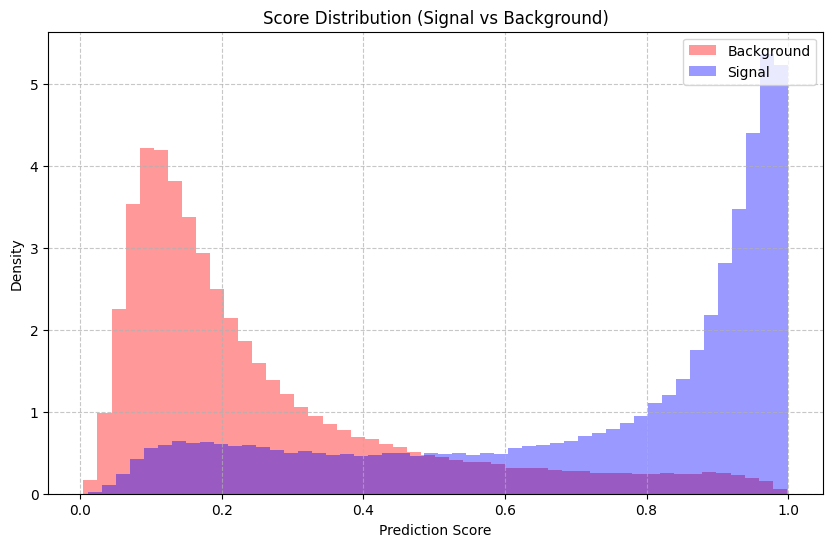

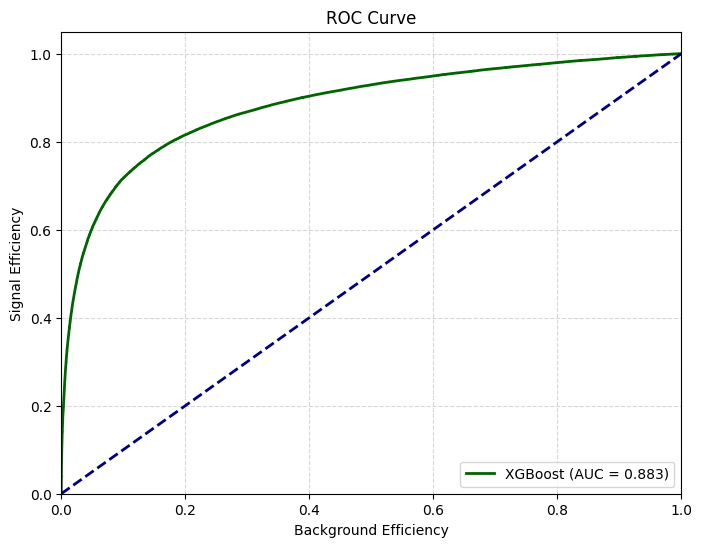

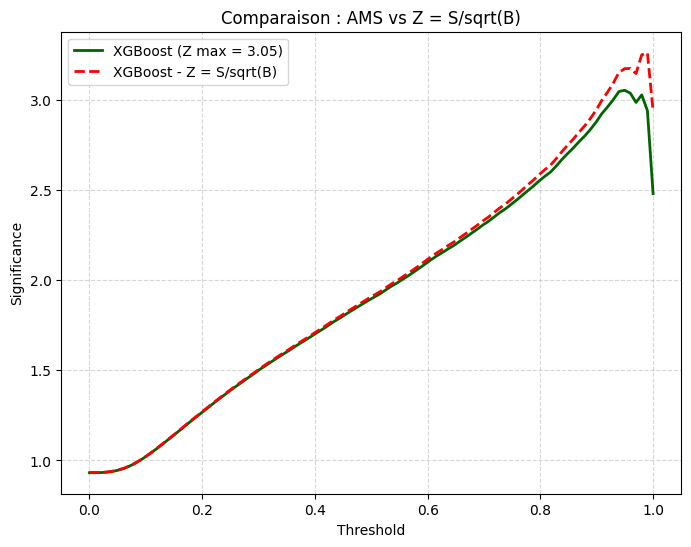

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
# --- 0. Normalisation poids ---
TARGET_S = 1015
TARGET_B = 1050370

sum_s_val = np.sum(weights_test[y_test == 1])
sum_b_val = np.sum(weights_test[y_test == 0])

factor_s = TARGET_S / sum_s_val
factor_b = TARGET_B / sum_b_val

weights_test_arr = weights_test.copy()
weights_test_arr[y_test == 1] *= factor_s
weights_test_arr [y_test==0] *= factor_b


# --- 1. COURBE SCORE ---

plot_score_distribution(y_test, y_pred_test, weights=weights_test_arr)




# --- 2. COURBE ROC AUC ---

plt.figure(figsize=(8, 6))
auc_test = roc_auc_score(
    y_true=y_test, y_score=y_pred_test, sample_weight=weights_test_arr
    )
fpr, tpr, _ = roc_curve(
    y_true=y_test, y_score=y_pred_test, sample_weight=weights_test_arr
    )

plt.plot(fpr, tpr, color="darkgreen", lw=2,
             label=f"{model_name} (AUC = {auc_test:.3f})")

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Background Efficiency")
plt.ylabel("Signal Efficiency")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()






# --- 3. COURBE DE SIGNIFICATIVITÉ ---

vams, vsimple = significance_vscore(y_true=y_test, y_score=y_pred_test, sample_weight=weights_test_arr)

significance_max = significance_score(
    y_true=y_test, y_score=y_pred_test, sample_weight=weights_test_arr
    )
x_thresholds = np.linspace(0, 1, num=len(vams))

plt.figure(figsize=(8, 6))
plt.plot(x_thresholds, vams, color="darkgreen", lw=2,label=f"{model_name} (Z max = {significance_max:.2f})"
             )
plt.plot(x_thresholds, vsimple, color="red", lw=2, linestyle="--", label=f"{model_name} - Z = S/sqrt(B)")

plt.title("Comparaison : AMS vs Z = S/sqrt(B)")
plt.xlabel("Threshold")
plt.ylabel("Significance")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()